**IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

**LOAD DATASET**

In [ ]:
df = pd.read_excel(
    "Coffee_Shop_Sales_Nusantara_Clean.xlsx"
)

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Surabaya,C005,22000,Coffee,Kopi Lokal Nusantara,Es Kopi Susu Gula Aren Rg
1,2,2023-01-01,07:08:56,2,2,Bandung,TE06,15000,Tea,Teh Nusantara & Klasik,Teh Kampul Solo
2,3,2023-01-01,07:14:04,2,1,Jakarta Pusat,T005,35000,Minuman Tradisional & Cokelat,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Surabaya,C011,25000,Coffee,Single Origin Indonesia,Bali Kintamani Sm
4,5,2023-01-01,07:22:41,2,2,Bandung,TE06,15000,Tea,Teh Nusantara & Klasik,Teh Kampul Solo


**EDA**

In [ ]:
print(df.shape)

df.info()

(147164, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147164 entries, 0 to 147163
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    147164 non-null  int64         
 1   transaction_date  147164 non-null  datetime64[ns]
 2   transaction_time  147164 non-null  object        
 3   transaction_qty   147164 non-null  int64         
 4   store_id          147164 non-null  int64         
 5   store_location    147164 non-null  object        
 6   product_id        147164 non-null  object        
 7   unit_price        147164 non-null  int64         
 8   product_category  147164 non-null  object        
 9   product_type      147164 non-null  object        
 10  product_detail    147164 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(6)
memory usage: 12.4+ MB


In [ ]:
df.describe(include='all')

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
count,147164.000000,147164,147164,147164.000000,147164.000000,147164,147164,147164.000000,147164,147164,147164
unique,NaN,NaN,25749,NaN,NaN,5,50,NaN,7,14,50
top,NaN,NaN,09:31:15,NaN,NaN,Yogyakarta,TE01,NaN,Coffee,Teh Nusantara & Klasik,Es Teh Manis Lg
freq,NaN,NaN,41,NaN,NaN,29674,8321,NaN,52911,46659,8321
mean,74726.551874,2023-04-15 11:30:08.757576448,NaN,1.443865,3.003921,NaN,NaN,23199.403387,NaN,NaN,NaN
min,1.000000,2023-01-01 00:00:00,NaN,1.000000,1.000000,NaN,NaN,8000.000000,NaN,NaN,NaN
25%,37302.750000,2023-03-06 00:00:00,NaN,1.000000,2.000000,NaN,NaN,15000.000000,NaN,NaN,NaN
50%,74707.500000,2023-04-24 00:00:00,NaN,1.000000,3.000000,NaN,NaN,20000.000000,NaN,NaN,NaN
75%,112098.250000,2023-05-30 00:00:00,NaN,2.000000,4.000000,NaN,NaN,28000.000000,NaN,NaN,NaN
max,149456.000000,2023-06-30 00:00:00,NaN,8.000000,5.000000,NaN,NaN,145000.000000,NaN,NaN,NaN


In [ ]:
# Missing value
df.isnull().sum()

,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [ ]:
# Duplicate
df.duplicated().sum()

np.int64(0)

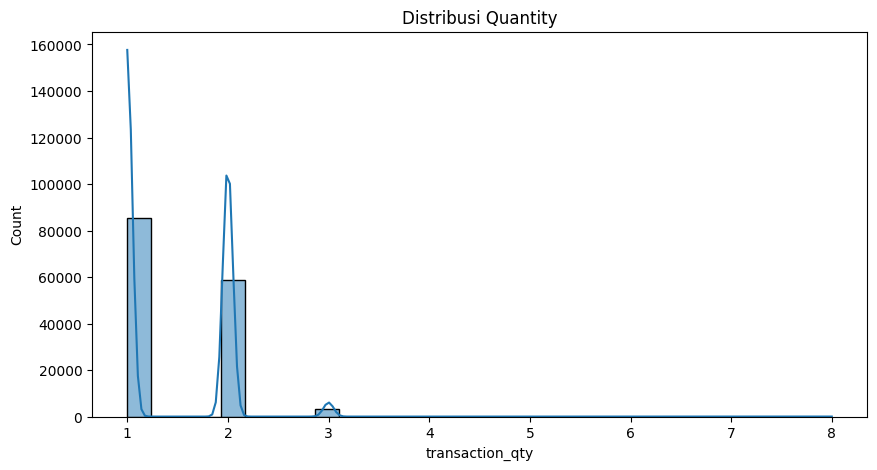

In [ ]:
# Distribusi Quantity
plt.figure(figsize=(10,5))

sns.histplot(
    df['transaction_qty'],
    bins=30,
    kde=True
)

plt.title("Distribusi Quantity")
plt.show()

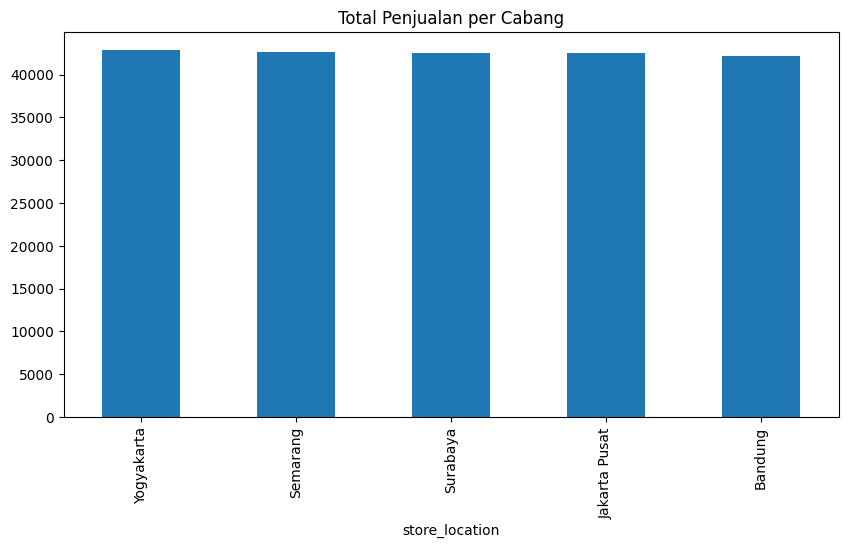

In [ ]:
# Penjualan per Cabang
branch_sales = (
    df.groupby('store_location')
    ['transaction_qty']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

branch_sales.plot(kind='bar')

plt.title("Total Penjualan per Cabang")

plt.show()

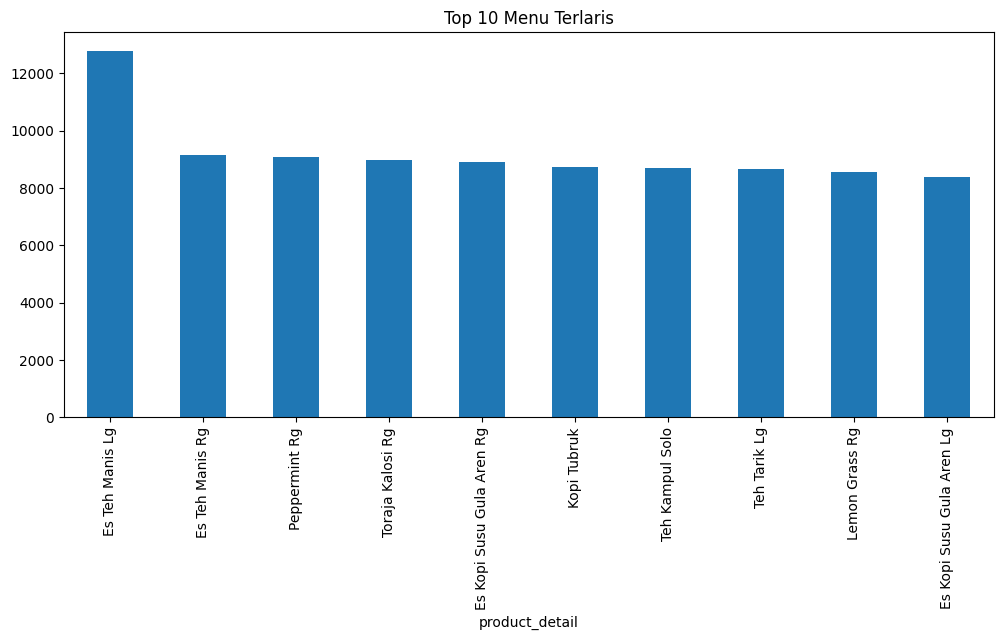

In [ ]:
# Top Menu
top_menu = (
    df.groupby('product_detail')
    ['transaction_qty']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_menu.plot(kind='bar')

plt.title("Top 10 Menu Terlaris")

plt.show()

In [ ]:
df['transaction_date'] = pd.to_datetime(
    df['transaction_date']
)

In [ ]:
monthly_trend = (
    df.groupby(
        pd.Grouper(
            key='transaction_date',
            freq='M'
        )
    )['transaction_qty']
    .sum()
)

/tmp/ipykernel_2574/2606309066.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


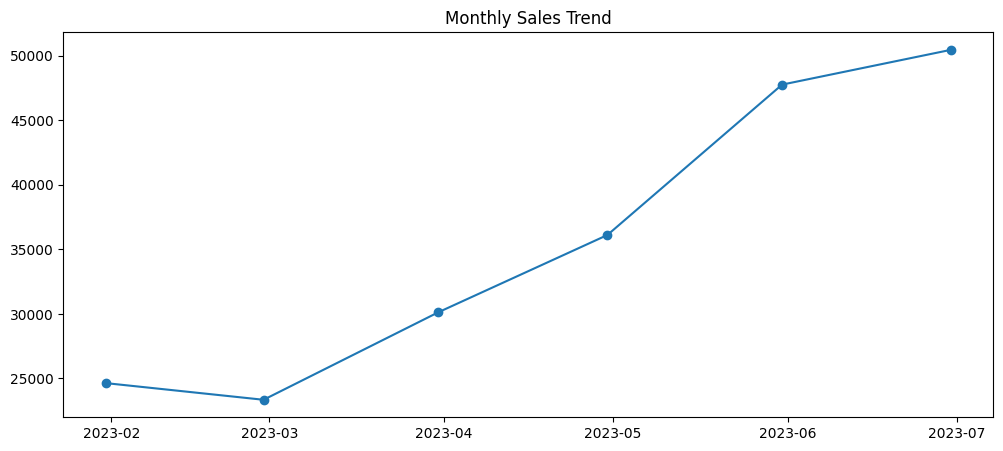

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_trend.index,
    monthly_trend.values,
    marker='o'
)

plt.title(
    'Monthly Sales Trend'
)

plt.show()

**DATA PREPARATION**

In [ ]:
# Agregasi Bulanan
df['year_month'] = (
    df['transaction_date']
    .dt.to_period('M')
)

In [ ]:
monthly_sales = (
    df.groupby(
        [
            'year_month',
            'store_location',
            'product_detail'
        ]
    )['transaction_qty']
    .sum()
    .reset_index()
)

In [ ]:
# Tambahkan Informasi Produk
product_info = df[
    [
        'product_detail',
        'product_category',
        'product_type',
        'unit_price'
    ]
].drop_duplicates()

In [ ]:
monthly_sales = monthly_sales.merge(
    product_info,
    on='product_detail',
    how='left'
)

In [ ]:
# Fitur Waktu
monthly_sales['year_month_dt'] = pd.to_datetime(
    monthly_sales['year_month'].astype(str)
)

In [ ]:
monthly_sales['year'] = (
    monthly_sales['year_month_dt']
    .dt.year
)

monthly_sales['month'] = (
    monthly_sales['year_month_dt']
    .dt.month
)

monthly_sales['quarter'] = (
    monthly_sales['year_month_dt']
    .dt.quarter
)

In [ ]:
# Encoding
branch_encoder = LabelEncoder()
product_encoder = LabelEncoder()
category_encoder = LabelEncoder()
type_encoder = LabelEncoder()

In [ ]:
monthly_sales['branch_encoded'] = (
    branch_encoder.fit_transform(
        monthly_sales['store_location']
    )
)

monthly_sales['product_encoded'] = (
    product_encoder.fit_transform(
        monthly_sales['product_detail']
    )
)

monthly_sales['category_encoded'] = (
    category_encoder.fit_transform(
        monthly_sales['product_category']
    )
)

monthly_sales['type_encoded'] = (
    type_encoder.fit_transform(
        monthly_sales['product_type']
    )
)

In [ ]:
# Sorting
monthly_sales = monthly_sales.sort_values(
    [
        'store_location',
        'product_detail',
        'year_month_dt'
    ]
)

In [ ]:
# Lag Features
group_cols = [
    'store_location',
    'product_detail'
]

In [ ]:
monthly_sales['lag_1'] = (
    monthly_sales.groupby(group_cols)
    ['transaction_qty']
    .shift(1)
)

monthly_sales['lag_3'] = (
    monthly_sales.groupby(group_cols)
    ['transaction_qty']
    .shift(3)
)

monthly_sales['lag_6'] = (
    monthly_sales.groupby(group_cols)
    ['transaction_qty']
    .shift(6)
)

In [ ]:
# Rolling Features
monthly_sales['rolling_3'] = (
    monthly_sales.groupby(group_cols)
    ['transaction_qty']
    .transform(
        lambda x: x.rolling(3).mean()
    )
)

monthly_sales['rolling_6'] = (
    monthly_sales.groupby(group_cols)
    ['transaction_qty']
    .transform(
        lambda x: x.rolling(6).mean()
    )
)

In [ ]:
# Feature Selection
FEATURES = [

    'branch_encoded',
    'product_encoded',

    'category_encoded',
    'type_encoded',

    'unit_price',

    'year',
    'month',
    'quarter',

    'lag_1',
    'lag_3',
    'lag_6',

    'rolling_3',
    'rolling_6'
]

In [ ]:
TARGET = 'transaction_qty'

In [ ]:
X = monthly_sales[FEATURES]
y = monthly_sales[TARGET]

In [ ]:
# Split Berdasarkan Waktu
monthly_sales = monthly_sales.sort_values(
    'year_month_dt'
)

In [ ]:
split_idx = int(
    len(monthly_sales) * 0.8
)

In [ ]:
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

**TRAINING XGBOOST**

In [ ]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [ ]:
model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

**EVALUASI**

In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

mape = np.mean(
    np.abs(
        (y_test - y_pred)
        / y_test
    )
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)
print("MAPE:", mape)

MAE : 9.568243980407715
RMSE: 14.305670962233386
R2 : 0.9862349629402161
MAPE: 15.336399262148973


In [ ]:
X_test_copy = monthly_sales.iloc[
    split_idx:
].copy()

In [ ]:
result_df = pd.DataFrame({
    'Month': X_test_copy['year_month'].astype(str).values,
    'Branch': X_test_copy['store_location'].values,
    'Product': X_test_copy['product_detail'].values,
    'Actual_Qty': y_test.values,
    'Predicted_Qty': np.round(y_pred,2)
})

In [ ]:
result_df['Error'] = (
    result_df['Actual_Qty']
    - result_df['Predicted_Qty']
)

result_df['Abs_Error'] = (
    result_df['Error'].abs()
)

In [ ]:
result_df.head(20)

,Month,Branch,Product,Actual_Qty,Predicted_Qty,Error,Abs_Error
0,2023-05,Bandung,Wedang Jahe Merah,208,186.130005,21.869995,21.869995
1,2023-05,Surabaya,Chocolate Croissant,196,159.500000,36.500000,36.500000
2,2023-05,Bandung,Es Teh Manis Rg,192,225.119995,-33.119995,33.119995
3,2023-05,Bandung,Wedang Uwuh,247,282.660004,-35.660004,35.660004
4,2023-05,Bandung,Teh Poci Gula Batu,361,325.149994,35.850006,35.850006
5,2023-05,Surabaya,Carmel syrup,389,391.630005,-2.630005,2.630005
6,2023-05,Bandung,Teh Kampul Solo,45,46.459999,-1.459999,1.459999
7,2023-05,Bandung,Es Kopi Susu Gula Aren Rg,33,40.290001,-7.290001,7.290001
8,2023-05,Surabaya,Pandan syrup,47,50.630001,-3.630001,3.630001
9,2023-05,Bandung,Risoles Mayo,70,62.770000,7.230000,7.230000


In [ ]:
branch_summary = (
    result_df.groupby('Branch')
    .agg({
        'Actual_Qty':'sum',
        'Predicted_Qty':'sum'
    })
    .reset_index()
)

branch_summary

,Branch,Actual_Qty,Predicted_Qty
0,Bandung,9162,9162.990234
1,Jakarta Pusat,11769,11648.099609
2,Semarang,6773,6752.479980
3,Surabaya,6615,6622.680176
4,Yogyakarta,8494,8552.160156


**ACTUAL VS PREDICTION**

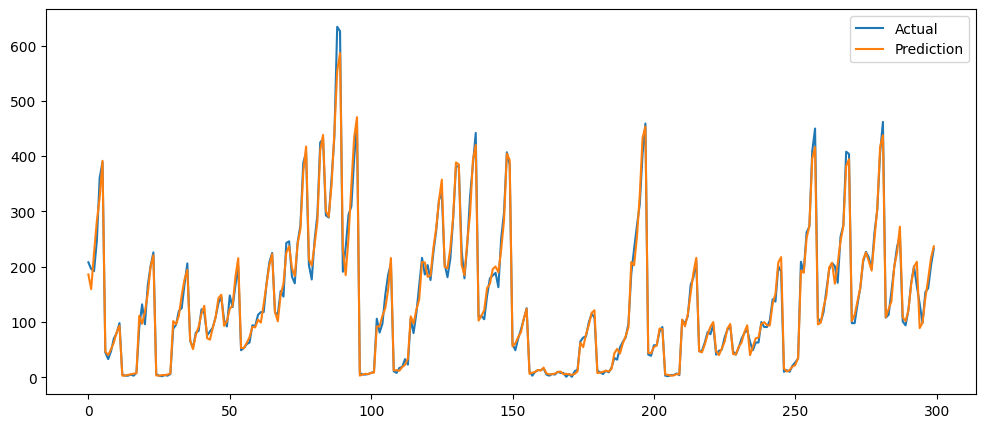

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    y_pred,
    label='Prediction'
)

plt.legend()

plt.show()

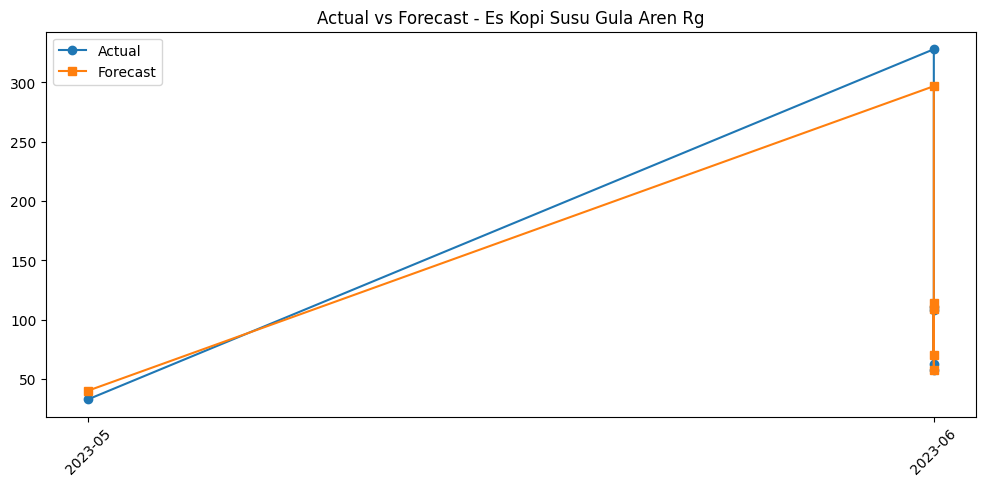

In [ ]:
product_name = 'Es Kopi Susu Gula Aren Rg'

plot_df = result_df[
    result_df['Product']
    == product_name
]

plt.figure(figsize=(12,5))

plt.plot(
    plot_df['Month'],
    plot_df['Actual_Qty'],
    marker='o',
    label='Actual'
)

plt.plot(
    plot_df['Month'],
    plot_df['Predicted_Qty'],
    marker='s',
    label='Forecast'
)

plt.legend()

plt.title(
    f'Actual vs Forecast - {product_name}'
)

plt.xticks(rotation=45)

plt.show()

**RESIDUAL ANALYSIS**

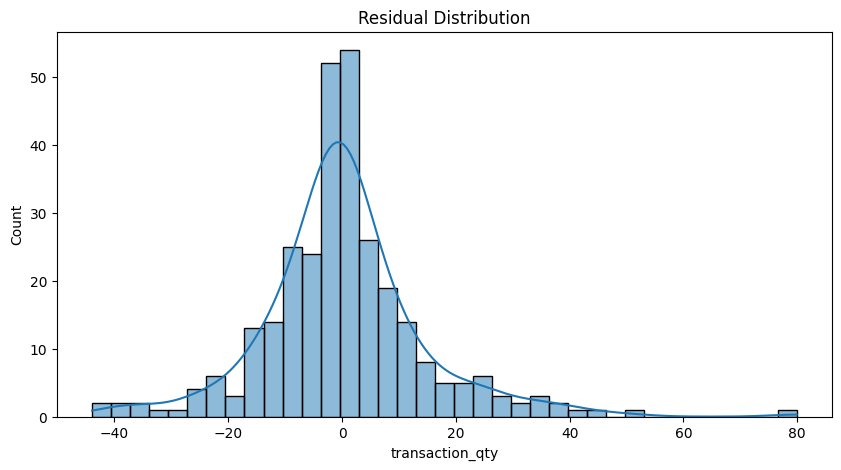

In [ ]:
residual = y_test - y_pred

plt.figure(figsize=(10,5))

sns.histplot(
    residual,
    kde=True
)

plt.title(
    'Residual Distribution'
)

plt.show()

**FEATURE IMPORTANCE**

In [ ]:
importance = pd.DataFrame({
    'Feature':FEATURES,
    'Importance':model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

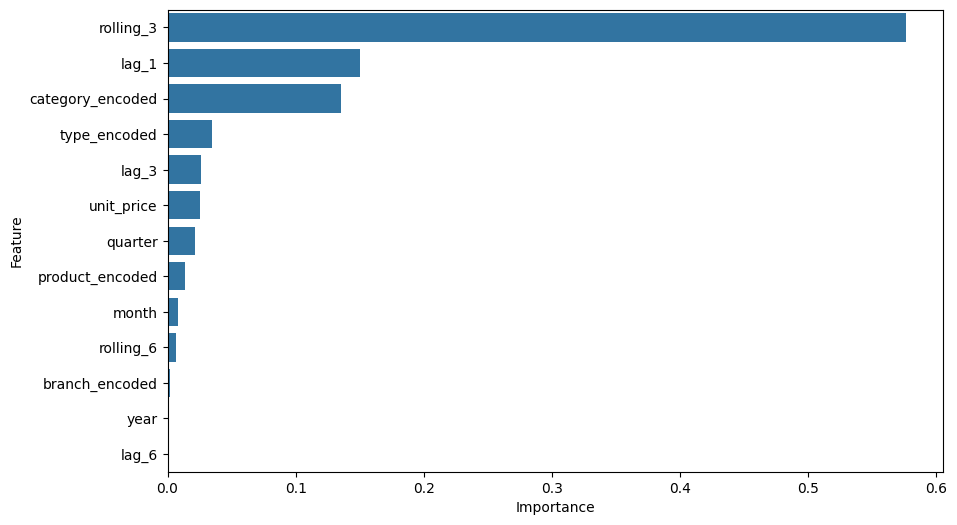

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.show()

**SAVE MODEL**

In [ ]:
joblib.dump(
    model,
    'forecast_monthly_menu_branch.pkl'
)

joblib.dump(
    branch_encoder,
    'branch_encoder.pkl'
)

joblib.dump(
    product_encoder,
    'product_encoder.pkl'
)

joblib.dump(
    category_encoder,
    'category_encoder.pkl'
)

joblib.dump(
    type_encoder,
    'type_encoder.pkl'
)

['type_encoder.pkl']

In [ ]:
# SAVE hasil prediksi
result_df.to_excel(
    'monthly_actual_vs_prediction.xlsx',
    index=False
)